## ABIDES normal market config simulation analysis

This notebook analyzes the statistical properties of the ABIDES LOB simulation using the `normal_market_config_w_OBI_agents` configuration.

The configuration defines a synthetic market environment populated by various autonomous agents, including Noise Agents, Value Agents, Momentum Agents, and an Execution Agent. The following analyses are performed:

- Comparison between the simulated market mid-price and the fundamental value series.
- Correlation analysis between bid–ask spreads and market volatility.
- Visual inspection of returns and rolling volatility over time.
- Analysis of statistical properties of returns (kurtosis, skewness, normality checks) at 1-second and 1-minute aggregations.
- Autocorrelation function (ACF) plots for raw returns and squareed returns.
- Correlation between trading volume and price volatility.
- Volume distribution analysis.
- Price impact curve (Kyle's lambda) analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats
import seaborn as sns
import os
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf

In [2]:
# Import data files

LOG_DIR = "../abides_core/log/normal_market_configuration_with_OIB_agents"

files = {
    "exchange": os.path.join(LOG_DIR, "EXCHANGE_AGENT.bz2"),
    "fundamental": os.path.join(LOG_DIR, "fundamental_ABM.bz2"),
    "orderbook": os.path.join(LOG_DIR, "ORDERBOOK_ABM_FULL.bz2"),
    "pov_agent": os.path.join(LOG_DIR, "POV_EXECUTION_AGENT.bz2"),
    "summary": os.path.join(LOG_DIR, "summary_log.bz2")
}

try:
    # Exchange Log of all events 
    df_exchange = pd.read_pickle(files["exchange"])
    print(f"Number of messages sent throughout the simulation by the agents: {df_exchange.shape[0]} rows")

    # Fundamental Price Log 
    df_fundamental = pd.read_pickle(files["fundamental"])

    # Orderbook Log 
    df_orderbook = pd.read_pickle(files["orderbook"])
    print(f"Number of orderbook executions: {df_orderbook.shape[0]} rows")

    # Summary Log that contains the end balances and statistics for the agents
    df_summary = pd.read_pickle(files["summary"])

except Exception as e:
    print(f"\nERROR loading pickles: {e}")

Number of messages sent throughout the simulation by the agents: 2145322 rows
Number of orderbook executions: 233239 rows


### Comparison between the simulated market mid-price and the fundamental value series

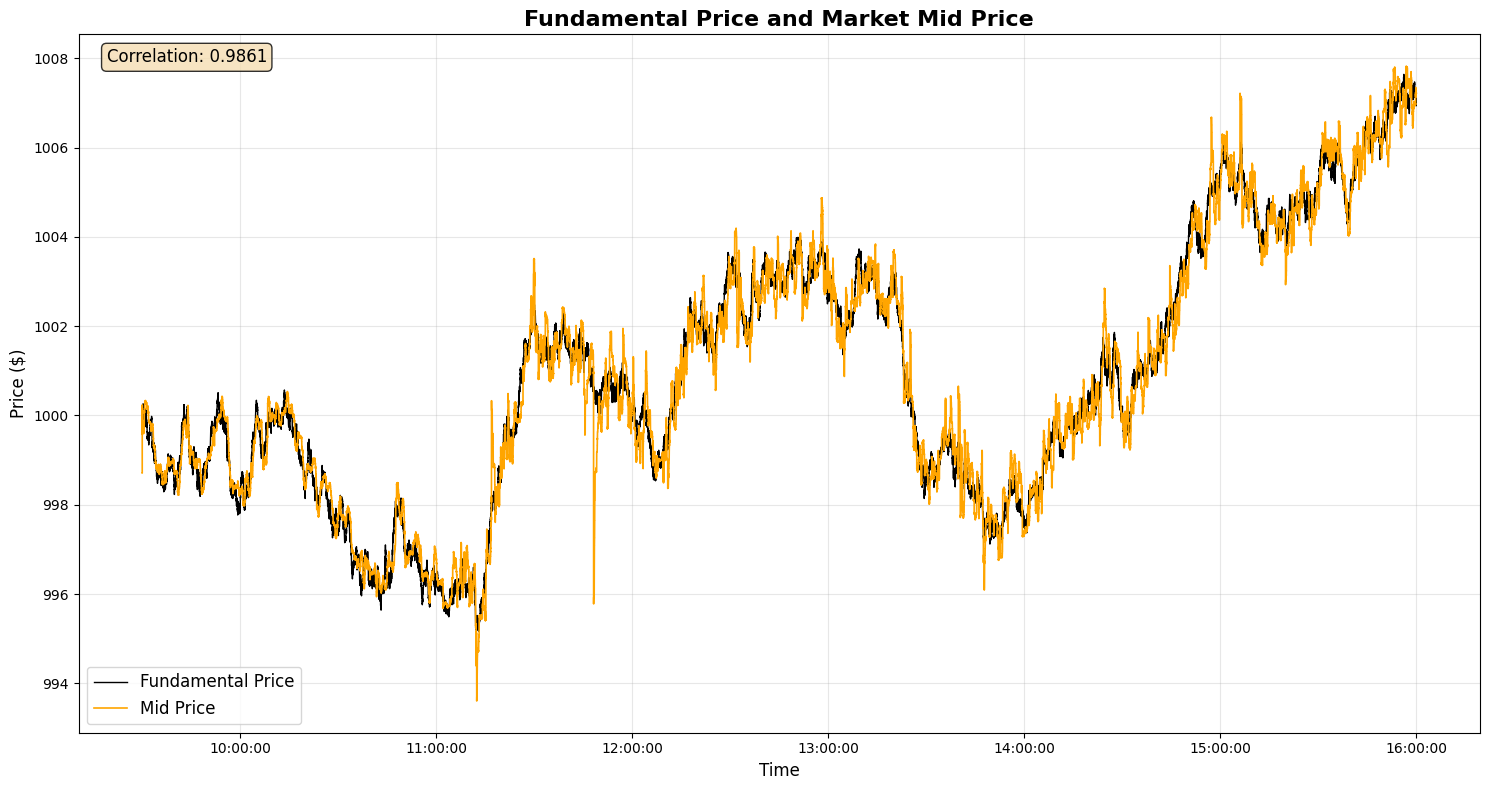

In [3]:
best_bid_prices = []
best_ask_prices = []
mid_prices = []
spreads = []

for timestamp, row in df_orderbook.iterrows():
    bid_levels = row[row<0] # Bids are negative prices in the orderbook dataframe
    best_bid = bid_levels.index.max() if not bid_levels.empty else np.nan

    ask_levels = row[row>0]
    best_ask = ask_levels.index.min() if not ask_levels.empty else np.nan

    if not np.isnan(best_bid) and not np.isnan(best_ask):
        bid_dollar = best_bid / 100.0 # Convert from cents to dollars
        ask_dollar = best_ask / 100.0

        mid_prices.append((bid_dollar + ask_dollar) / 2)
        spreads.append(ask_dollar - bid_dollar)
        best_bid_prices.append(bid_dollar)
        best_ask_prices.append(ask_dollar)

    else:
        mid_prices.append(np.nan)
        spreads.append(np.nan)
        best_bid_prices.append(np.nan)
        best_ask_prices.append(np.nan)

df_prices = pd.DataFrame({
    "best_bid": best_bid_prices,
    "best_ask": best_ask_prices,
    "mid_price": mid_prices,
    "spread": spreads
}, index=df_orderbook.index)

# There are 52 NaN values in the beginning of the series due to no bids/asks 
# in the orderbook. This is irrelevant for the plot so we backfill them
df_prices.bfill()

df_fund_clean = df_fundamental.copy()
df_fund_clean['fundamental_price'] = df_fundamental['FundamentalValue'] / 100.0

start_time = max(df_fund_clean.index.min(), df_prices.index.min())
end_time = min(df_fund_clean.index.max(), df_prices.index.max())

df_aligned = pd.DataFrame({
    'fundamental_price': df_fund_clean.loc[start_time:end_time, 'fundamental_price'],
    'mid_price': df_prices.loc[start_time:end_time, 'mid_price']
})

# There are mismatches in timestamps, we forward fill the missing values
df_aligned.ffill(inplace=True)
df_aligned.bfill(inplace=True)


# Plot 
plt.figure(figsize=(15, 8))

plt.plot(df_aligned.index, df_aligned['fundamental_price'], 
         label='Fundamental Price', color='black', linewidth=1)
plt.plot(df_aligned.index, df_aligned['mid_price'], 
         label='Mid Price', color='orange', linewidth=1.2, alpha=1)

plt.title('Fundamental Price and Market Mid Price', fontsize=16, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12)
plt.xlabel('Time', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

corr_text = f"Correlation: {df_aligned['fundamental_price'].corr(df_aligned['mid_price']):.4f}"
plt.text(0.02, 0.98, corr_text, transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=12, verticalalignment='top')

plt.tight_layout()
plt.savefig("normal_market_analysis_w_OBI_agents_plots/fundamental_vs_mid_price.png", dpi=300, bbox_inches="tight")
plt.show()


In [4]:
# We drop the NaN values from the beginnign of the orderbook (31 NaN values)
df_prices = df_prices.dropna()

### Correlation analysis between bid–ask spreads and market volatility

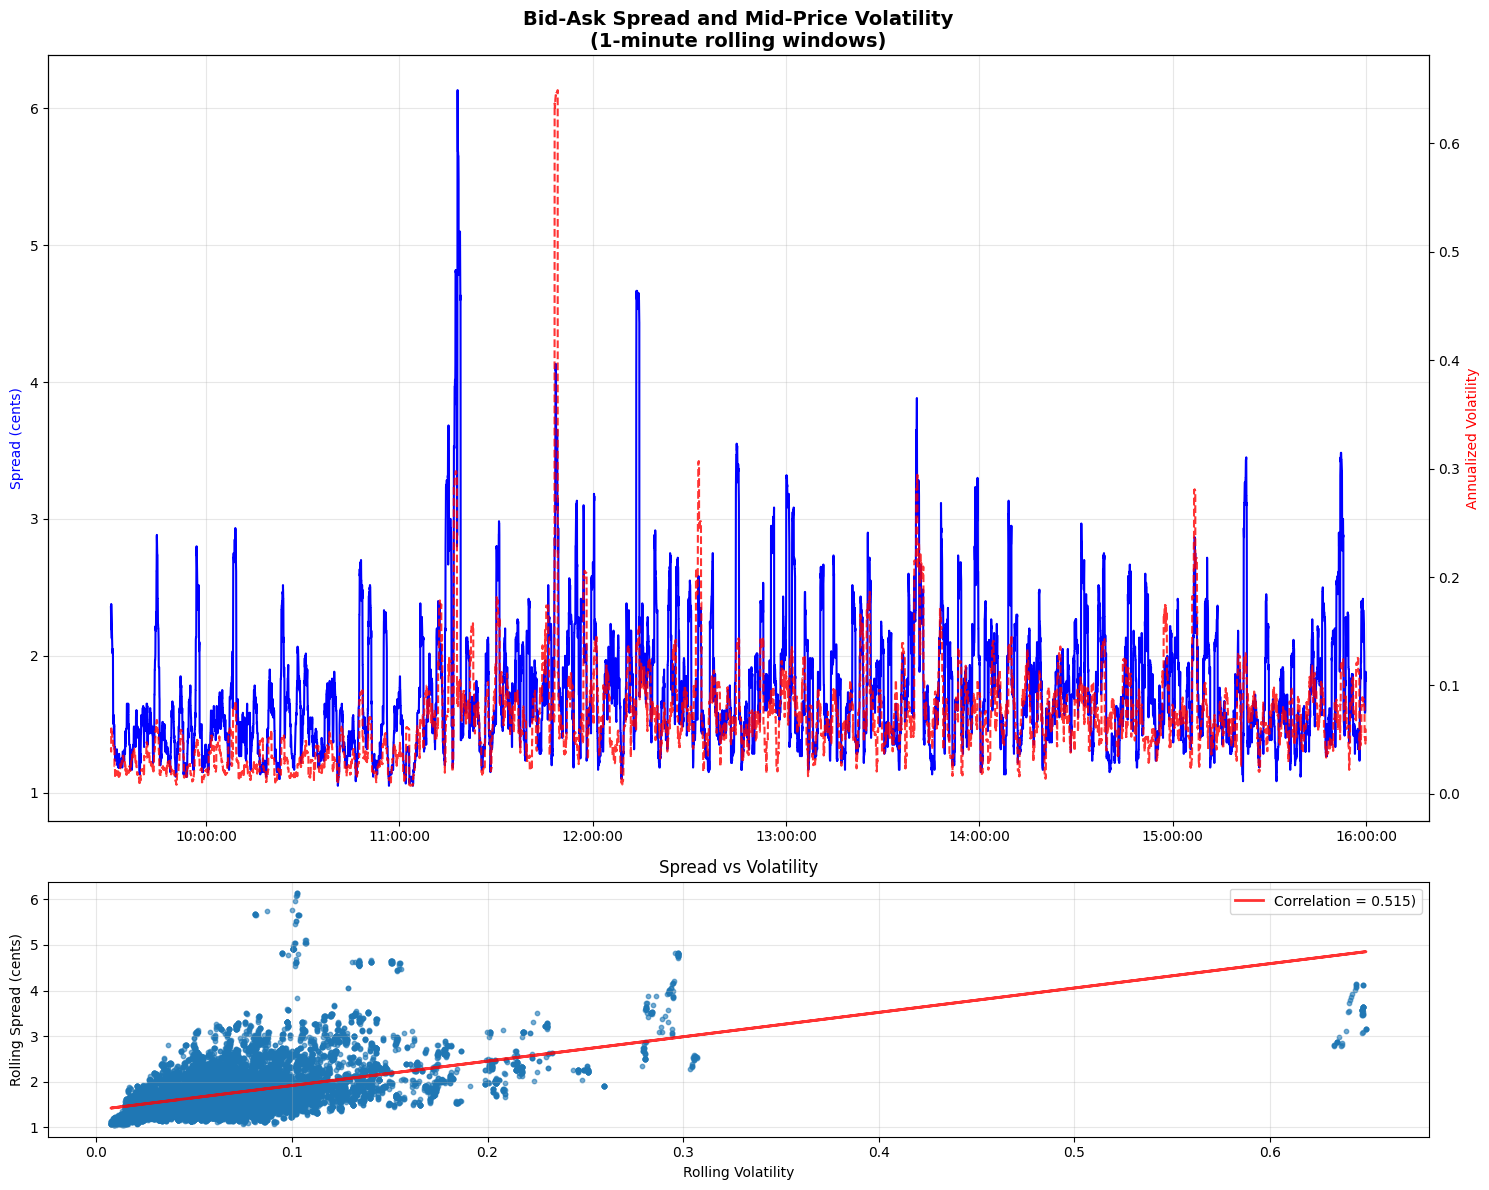

In [5]:

df_prices_resampled = df_prices.resample('1s').last().ffill()

log_returns = np.log(df_prices_resampled["mid_price"]/df_prices_resampled["mid_price"].shift(1))

window = 60
rolling_vol = log_returns.rolling(window=window, min_periods=window//2).std()*np.sqrt(252*60*60)
rolling_spread = df_prices_resampled["spread"].rolling(window=window, min_periods=window//2).mean()
    
df_vol_spread = pd.DataFrame({
    "rolling_volatility": rolling_vol,
    "rolling_spread": rolling_spread
}).dropna() # Due to the min_periods we obtain NaN values in the beginning. 

correlation = df_vol_spread["rolling_volatility"].corr(df_vol_spread["rolling_spread"])

# Plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), height_ratios=[3, 1])

# Upper plot of time series
ax1.plot(df_vol_spread.index, df_vol_spread['rolling_spread']*100,  # Scale to cents
         color='blue', label='Avg Spread (1-min)', linewidth=1.5)
ax1_twin = ax1.twinx()
ax1_twin.plot(df_vol_spread.index, df_vol_spread['rolling_volatility'], 
              color='red', linestyle='--', label='Volatility (1-min)', linewidth=1.5, alpha=0.8)
ax1.set_title('Bid-Ask Spread and Mid-Price Volatility\n(1-minute rolling windows)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Spread (cents)', color='blue')
ax1_twin.set_ylabel('Annualized Volatility', color='red')
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

# Lower scatter plot with correlation
scatter = ax2.scatter(df_vol_spread['rolling_volatility'], df_vol_spread['rolling_spread']*100, # Scale to cents
                    alpha=0.6, s=10)
ax2.set_xlabel('Rolling Volatility')
ax2.set_ylabel('Rolling Spread (cents)')
ax2.grid(True, alpha=0.3)

# # Add correlation text and trend line
z = np.polyfit(df_vol_spread['rolling_volatility'], df_vol_spread['rolling_spread'], 1)
p = np.poly1d(z)
ax2.plot(df_vol_spread['rolling_volatility'], p(df_vol_spread['rolling_volatility']) * 100, 
         "r-", alpha=0.8, lw=2, label=f'Correlation = {correlation:.3f})')

ax2.legend()
ax2.set_title('Spread vs Volatility')

plt.tight_layout()
plt.savefig("normal_market_analysis_w_OBI_agents_plots/spread_and_volatility.png", dpi=300, bbox_inches="tight")
plt.show()


### Visual inspection of returns and rolling volatility over time

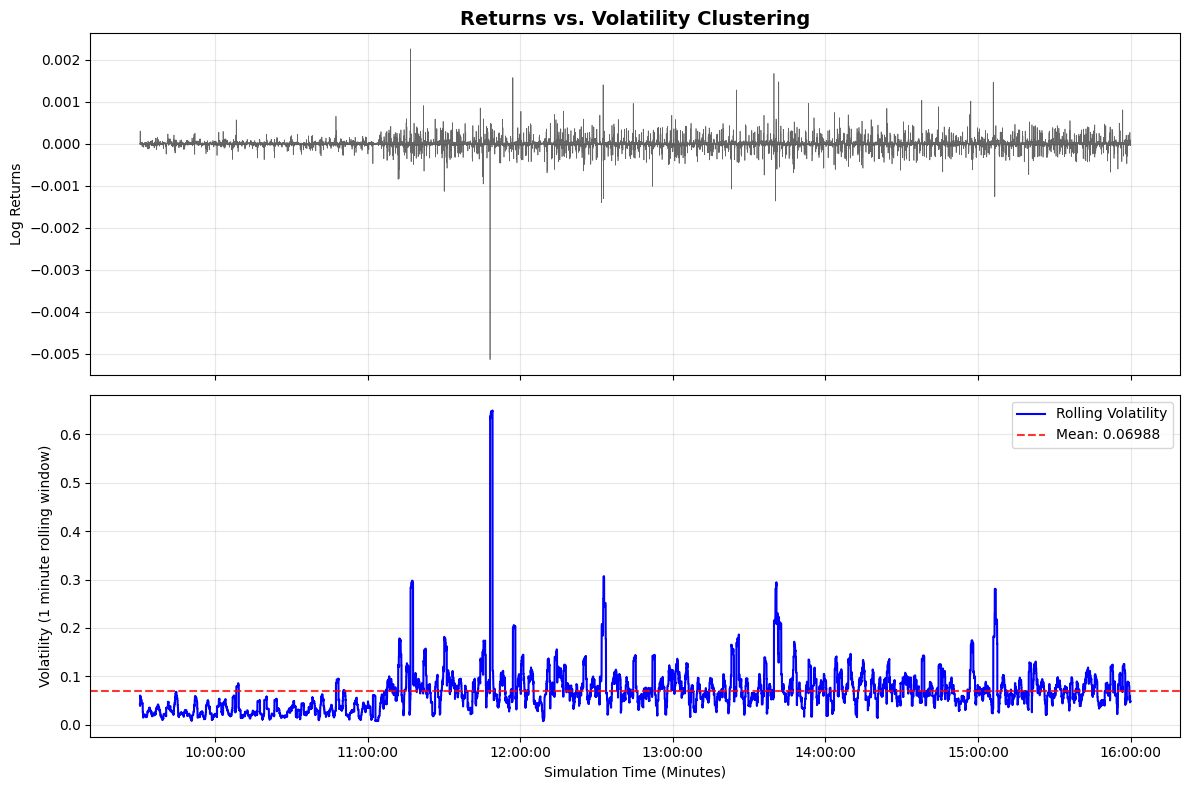

In [6]:
# Create the time axes
df_clustering = pd.DataFrame({
    'log_returns': log_returns,
    'rolling_volatility': df_vol_spread['rolling_volatility']
}).dropna()

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Log returns
ax1.plot(df_clustering.index, df_clustering['log_returns'], color='black', alpha=0.6, lw=0.5)
ax1.set_ylabel('Log Returns')
ax1.set_title('Returns vs. Volatility Clustering', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Rolling volatility 
ax2.plot(df_clustering.index, df_clustering['rolling_volatility'], color='blue', lw=1.5, label='Rolling Volatility')
mean_vol = df_clustering['rolling_volatility'].mean()
ax2.axhline(mean_vol, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_vol:.5f}')
ax2.set_ylabel('Volatility (1 minute rolling window)')
ax2.set_xlabel('Simulation Time (Minutes)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

plt.tight_layout()
plt.savefig("normal_market_analysis_w_OBI_agents_plots/returns_and_volatility_clustering.png", dpi=300, bbox_inches="tight")
plt.show()


### Analysis of statistical properties of returns (kurtosis, skewness, normality checks) at 1-second and 1-minute aggregations

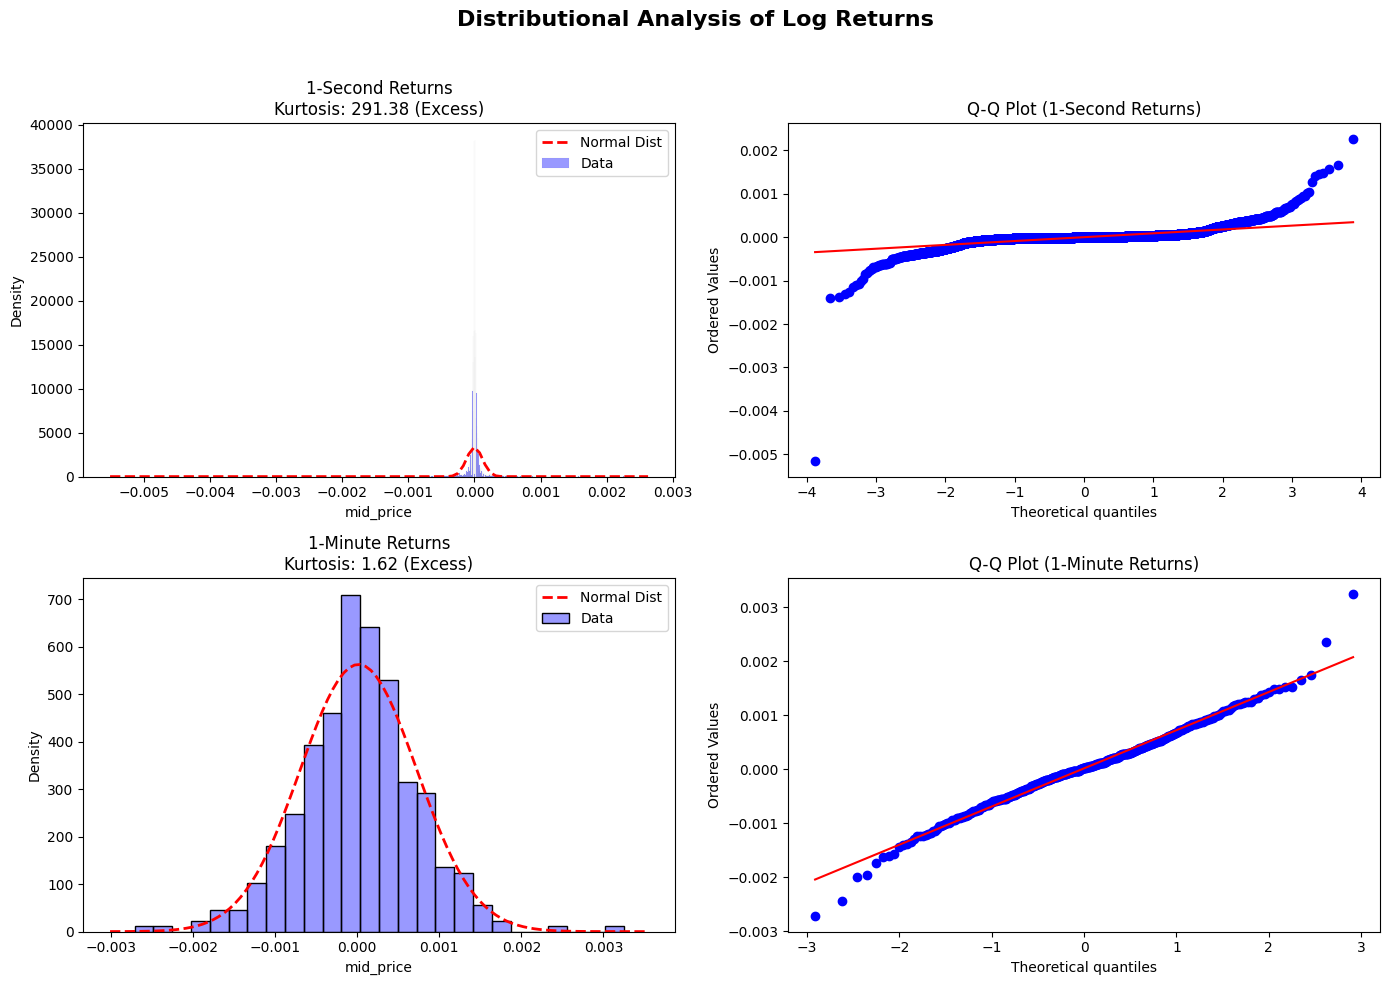

1-Sec Excess Kurtosis: 291.3827
1-Min Excess Kurtosis: 1.6195
1-Sec Skewness: -5.0647
1-Min Skewness: -0.0055


In [7]:
df_prices_resampled_minute = df_prices.resample('1min').last().ffill()
log_returns_minute = np.log(df_prices_resampled_minute["mid_price"]/df_prices_resampled_minute["mid_price"].shift(1))

log_returns_minute = log_returns_minute.dropna()
log_returns = log_returns.dropna() # Drop the first NaN values

log_returns_minute_no_zeros = log_returns_minute[log_returns_minute != 0] # Remove zero returns
log_returns_no_zeros = log_returns[log_returns != 0]

def plot_distribution_check(data, title, ax_hist, ax_qq):
    # Histogram
    sns.histplot(data, kde=False, stat="density", ax=ax_hist, color='blue', alpha=0.4, label='Data')
    
    # Overlay Normal Distribution
    mu, std = stats.norm.fit(data)
    xmin, xmax = ax_hist.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    ax_hist.plot(x, p, 'r--', linewidth=2, label='Normal Dist')
    ax_hist.set_title(f'{title}\nKurtosis: {stats.kurtosis(data):.2f} (Excess)')
    ax_hist.legend()
    
    # QQ Plot
    stats.probplot(data, dist="norm", plot=ax_qq)
    ax_qq.set_title(f'Q-Q Plot ({title})')

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.suptitle('Distributional Analysis of Log Returns', fontsize=16, fontweight='bold')

# 1-Second plots
plot_distribution_check(log_returns_no_zeros, "1-Second Returns", axes[0, 0], axes[0, 1])

# 1-Minute plots
plot_distribution_check(log_returns_minute_no_zeros, "1-Minute Returns", axes[1, 0], axes[1, 1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("normal_market_analysis_w_OBI_agents_plots/returns_distribution_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# Statistics
print(f"1-Sec Excess Kurtosis: {stats.kurtosis(log_returns_no_zeros):.4f}")
print(f"1-Min Excess Kurtosis: {stats.kurtosis(log_returns_minute_no_zeros):.4f}")
print(f"1-Sec Skewness: {stats.skew(log_returns_no_zeros):.4f}")
print(f"1-Min Skewness: {stats.skew(log_returns_minute_no_zeros):.4f}")

### Autocorrelation function (ACF) plots for log returns and squared log returns.

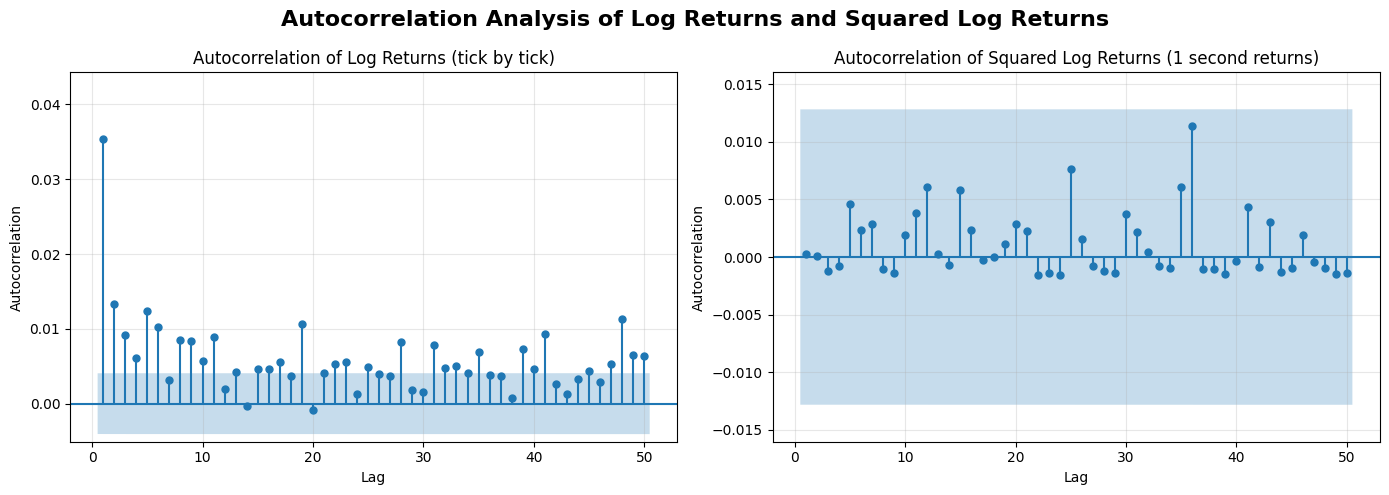

In [8]:
tick_log_returns = np.log(df_prices['mid_price'] / df_prices['mid_price'].shift(1)).dropna()
log_returns_squared = log_returns ** 2

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Autocorrelation Analysis of Log Returns and Squared Log Returns', fontsize=16, fontweight='bold')

# Plot log return lags
plot_acf(tick_log_returns, lags=50, ax=ax1, title='Autocorrelation of Log Returns (tick by tick)', zero=False, auto_ylims=True)
ax1.set_xlabel('Lag')
ax1.set_ylabel('Autocorrelation')
ax1.grid(True, alpha=0.3)

# Plot squared log return lags
plot_acf(log_returns_squared, lags=50, ax=ax2, title='Autocorrelation of Squared Log Returns (1 second returns)', zero=False, auto_ylims=True)
ax2.set_xlabel('Lag')
ax2.set_ylabel('Autocorrelation')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("normal_market_analysis_w_OBI_agents_plots/log_returns_autocorrelation_analysis.png", dpi=300, bbox_inches="tight")
plt.show()


### Correlation between trading volume and return volatility

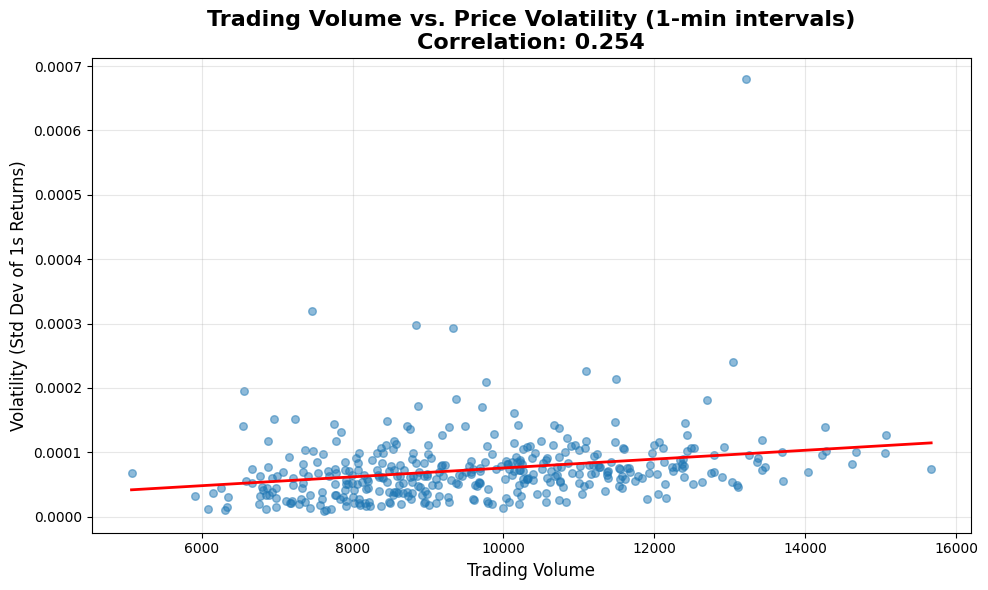

In [9]:
executed_orders = df_exchange[df_exchange['EventType'] == 'ORDER_EXECUTED'].copy()
executed_orders['volume'] = executed_orders['Event'].apply(lambda x: x['quantity'])
volume_1min = executed_orders['volume'].resample('1min').sum() / 2 # Divide by 2 because of double counting buy/sell sides

volatility_1min = log_returns.resample('1min').std()

df_vol_volume = pd.DataFrame({
    'volume': volume_1min,
    'volatility': volatility_1min
})

df_vol_volume = df_vol_volume.iloc[1:] # Drop first minute becasue at the beginning of the simulation the LOB is empty

corr = df_vol_volume['volume'].corr(df_vol_volume['volatility'])

# Plot 
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(x='volume', y='volatility', data=df_vol_volume, 
            scatter_kws={'alpha': 0.5, 's': 30}, 
            line_kws={'color': 'red', 'linewidth': 2},
            ci=None,
            ax=ax)

ax.set_title(f'Trading Volume vs. Price Volatility (1-min intervals)\nCorrelation: {corr:.3f}', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Trading Volume', fontsize=12)
ax.set_ylabel('Volatility (Std Dev of 1s Returns)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("normal_market_analysis_w_OBI_agents_plots/volume_vs_volatility.png", dpi=300, bbox_inches="tight")
plt.show()


### Volume distribution analysis

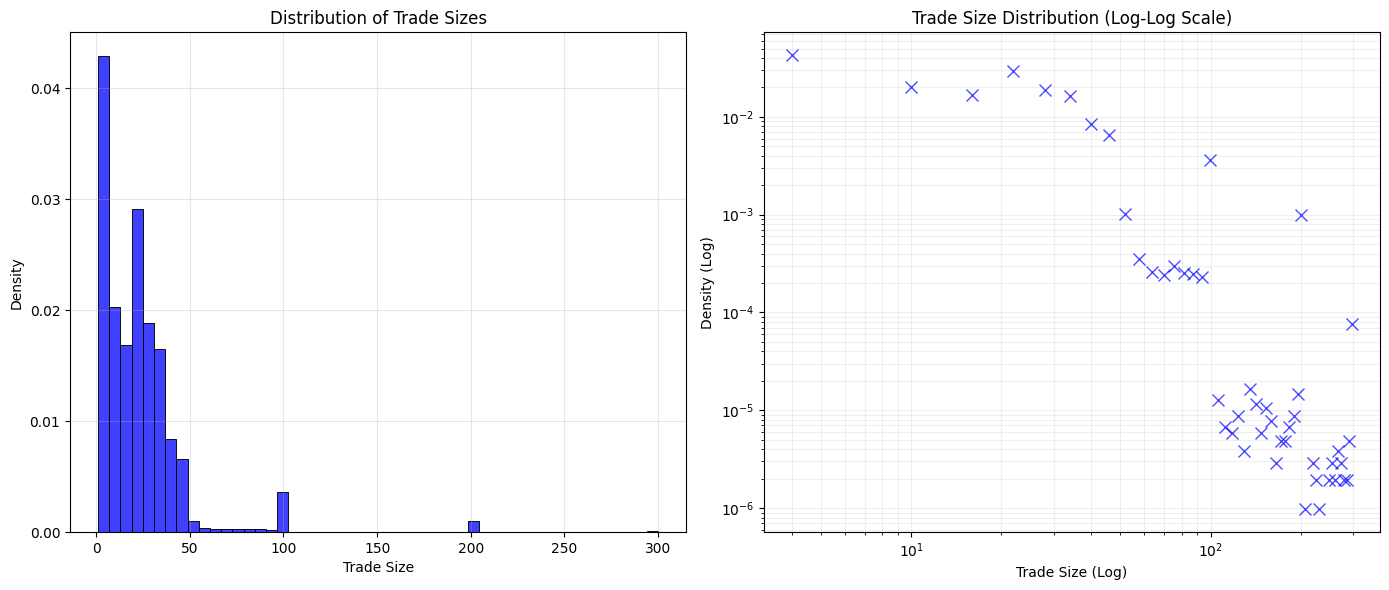

Skewness: 4.0717
Kurtosis: 27.0849


In [10]:

volumes = executed_orders['volume']

# Plot 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Histogram 
sns.histplot(volumes, bins=50, kde=False, ax=ax1, color='blue', stat='density')
ax1.set_title('Distribution of Trade Sizes')
ax1.set_xlabel('Trade Size')
ax1.set_ylabel('Density')
ax1.grid(True, alpha=0.3)

# Log-Log Plot
counts, bin_edges = np.histogram(volumes, bins=50, density=True)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

mask = counts > 0 # Remove zero counts for log scaling
centers = centers[mask]
counts = counts[mask]

ax2.loglog(centers, counts, 'bx', markersize=8, alpha=0.7)
ax2.set_title('Trade Size Distribution (Log-Log Scale)')
ax2.set_xlabel('Trade Size (Log)')
ax2.set_ylabel('Density (Log)')
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.savefig("normal_market_analysis_w_OBI_agents_plots/trade_size_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Skewness and Kurtosis
print(f"Skewness: {volumes.skew():.4f}")
print(f"Kurtosis: {volumes.kurtosis():.4f}")

### Price impact curve analysis

In [11]:
executed_orders['side'] = executed_orders['Event'].apply(lambda x: x['is_buy_order'])
executed_orders['signed_volume'] = executed_orders.apply(lambda row: row['volume'] if row['side'] else -row['volume'], axis=1)
executed_orders["time_placed"] = pd.to_datetime(executed_orders['Event'].apply(lambda x: x['time_placed']))
executed_orders["agent_id"] = executed_orders['Event'].apply(lambda x: x['agent_id'])

Here an important assumption is made. For the ORDER_EXECUTED event type, both sides of the order are recorded. This means that the net volume will always sum to zero and we always have pairs of order executions (Check EventTime index). The event information logs the time at which the orders were placed, and we assume that the aggressor (the one wanting to trade) places the order at a later point in time. To then obtain the actual net volume at a given point in time, we have to consider only the orders that were placed later (between each individual pair).

There are alse cases like the one in the bottom where tehre are more than 2 rows with the same EvetTime. Inspecting those showed that is was one order (the latest one) matching against multiple other resting orders, so the logic for getting the aggressing order is the same as with a pair of matched orders.  

In [12]:
def taker_signed_volume(group):
    tp_max = group["time_placed"].max()
    taker_rows = group[group["time_placed"] == tp_max]
    return taker_rows["signed_volume"].sum()

taker_flow = executed_orders.groupby(executed_orders.index).apply(taker_signed_volume)

net_volume_minute = taker_flow.resample('1min').sum()
net_volume_minute.name = 'net_volume'

net_volume_minute = net_volume_minute.iloc[1:] # Drop first minute since log_returns_minute has a NaN value

df_impact = pd.concat([log_returns_minute, net_volume_minute], axis=1)

X = df_impact['net_volume']
Y = df_impact['mid_price'] #TODO: Have to change the name to log_returns when creating the series

# Note: Standard Kyle's theory assumes no intercept (C=0), 
# but we usually add a constant to check for drift.
X_with_const = sm.add_constant(X)

model = sm.OLS(Y, X_with_const).fit()
lambda_kyle = model.params['net_volume']
r_squared = model.rsquared

print(f"Kyle's Lambda (Price Impact): {lambda_kyle:.2e}")
print(model.summary())

Kyle's Lambda (Price Impact): 7.03e-08
                            OLS Regression Results                            
Dep. Variable:              mid_price   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     30.32
Date:                Sat, 07 Feb 2026   Prob (F-statistic):           6.69e-08
Time:                        15:36:30   Log-Likelihood:                 2284.1
No. Observations:                 389   AIC:                            -4564.
Df Residuals:                     387   BIC:                            -4556.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9

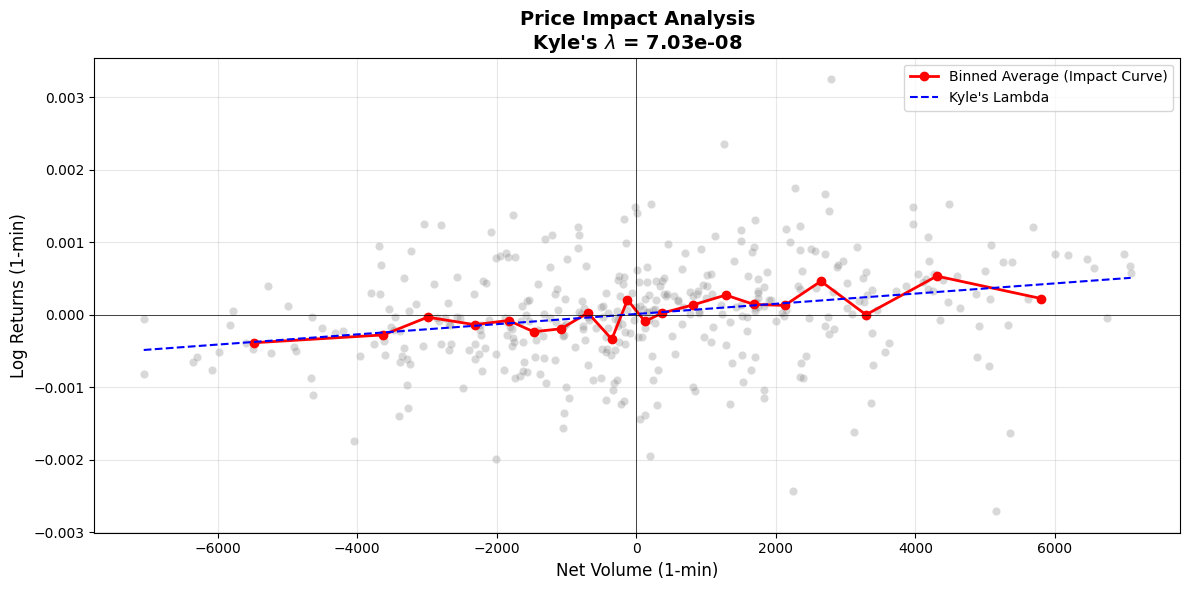

In [13]:
# Plot 
plt.figure(figsize=(12, 6))

# Scatter plot
sns.scatterplot(
    data=df_impact, 
    x='net_volume', 
    y='mid_price', 
    alpha=0.3, 
    color='gray', 
)

# Average Binned Impact Curve
df_impact['VolumeBin'] = pd.qcut(df_impact['net_volume'], q=20, duplicates='drop') # Divide net volume into 20 quantiles
binned_data = df_impact.groupby('VolumeBin', observed=True)[['net_volume', 'mid_price']].mean()
plt.plot(
    binned_data['net_volume'], 
    binned_data['mid_price'], 
    color='red', 
    marker='o', 
    linewidth=2, 
    label='Binned Average (Impact Curve)'
)

# Regression (Kyle's Lambda)
x_range = np.linspace(X.min(), X.max(), 100)
y_pred = model.params['const'] + lambda_kyle * x_range
plt.plot(x_range, y_pred, color='blue', linestyle='--', label=f"Kyle's Lambda")

plt.title(f'Price Impact Analysis\nKyle\'s $\lambda$ = {lambda_kyle:.2e}', fontsize=14, fontweight='bold')
plt.xlabel('Net Volume (1-min)', fontsize=12)
plt.ylabel('Log Returns (1-min)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig("normal_market_analysis_w_OBI_agents_plots/price_impact_analysis.png", dpi=300, bbox_inches="tight")
plt.show()
